In [8]:
%load_ext autoreload
%autoreload 2

import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [9]:
import torch
import numpy as np

emb_path = f"/home/luca/Documents/data/Visium_FFPE_Human_Breast_Cancer/lemon_embeddings.pt"
embeddings_dict = torch.load(emb_path)
embeddings = []
    
for embedding in embeddings_dict.values():
    embeddings.append(embedding.numpy())

embeddings = np.array(embeddings)
embeddings[0].shape

(384,)

In [10]:
image_path = "/home/luca/Documents/data/Visium_FFPE_Human_Breast_Cancer/image_dict_40.pt"
image_dict = torch.load(image_path)

In [11]:
import numpy as np
import json

hovernet_path = "/home/luca/Documents/data/Visium_FFPE_Human_Breast_Cancer/seg_json/pannuke_fast_mask_lvl3.json"
with open(hovernet_path) as json_file:
        data = json.load(json_file)
        hovernet_dict = data["nuc"]

labels = []
for cell_info in hovernet_dict.values():
    labels.append(cell_info['type'])
labels = np.array(labels)

# Perform Dimension Reduction

In [12]:
from utils.data_simulation import perform_umap

umap_embeddings = perform_umap(embeddings, n_neighbors=15, min_dist=0.1, n_components=2)

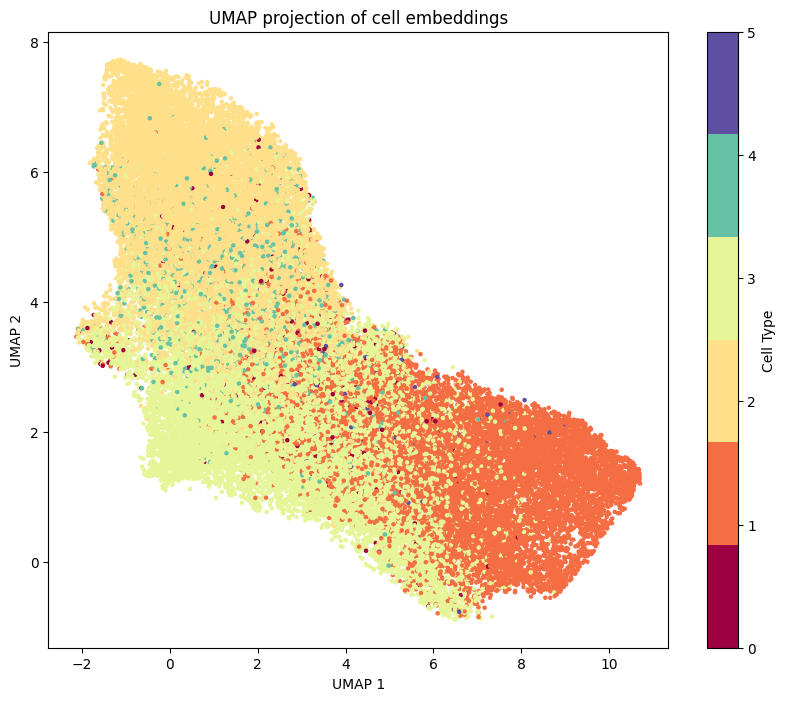

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
num_classes = len(np.unique(labels))
cmap = plt.get_cmap('Spectral', num_classes)
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=labels, cmap=cmap, s=5)
cbar = plt.colorbar(scatter, ticks=np.arange(num_classes))
cbar.set_label('Cell Type')

plt.title('UMAP projection of cell embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

# Perform clustering

In [18]:
from utils.data_simulation import perform_kmeans

n_clusters = 5
metric = 'euclidean'
random_state = 42

cluster_labels, distances, centroids = perform_kmeans(embeddings, 
                                                      n_clusters=n_clusters, 
                                                      metric=metric, 
                                                      random_state=random_state)

In [19]:
from utils.data_simulation import find_closest_cells_to_clusters

num_per_cluster = 1000

selected_indices = find_closest_cells_to_clusters(cluster_labels, distances, num_per_cluster=num_per_cluster)

filtered_embeddings = embeddings[selected_indices]
filtered_umap_embeddings = umap_embeddings[selected_indices]
filtered_labels = cluster_labels[selected_indices]
filtered_ids = np.array(list(image_dict.keys()))[selected_indices]

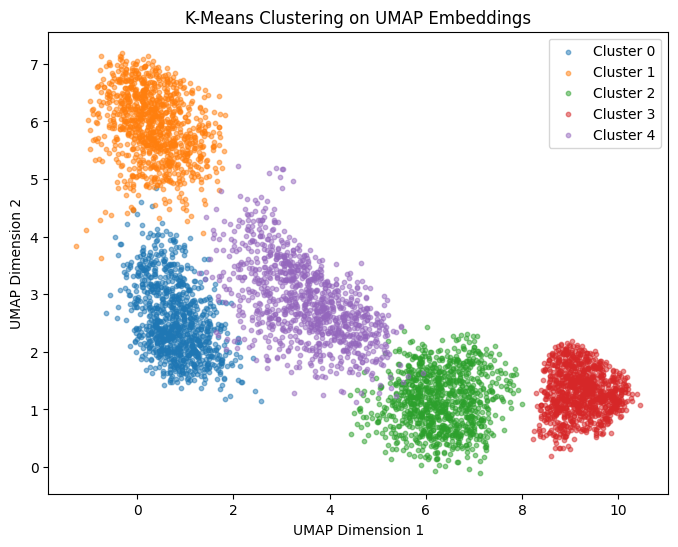

In [20]:
restricted = True

plt.figure(figsize=(8, 6))

for i in range(n_clusters):
    if restricted:
        plt.scatter(
            filtered_umap_embeddings[filtered_labels == i, 0], 
            filtered_umap_embeddings[filtered_labels == i, 1], 
            label=f'Cluster {i}', alpha=0.5, s=10
        )
    else:
        plt.scatter(
            umap_embeddings[cluster_labels == i, 0], 
            umap_embeddings[cluster_labels == i, 1], 
            label=f'Cluster {i}', alpha=0.5, s=10
        )

plt.legend()
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("K-Means Clustering on UMAP Embeddings")
plt.show()

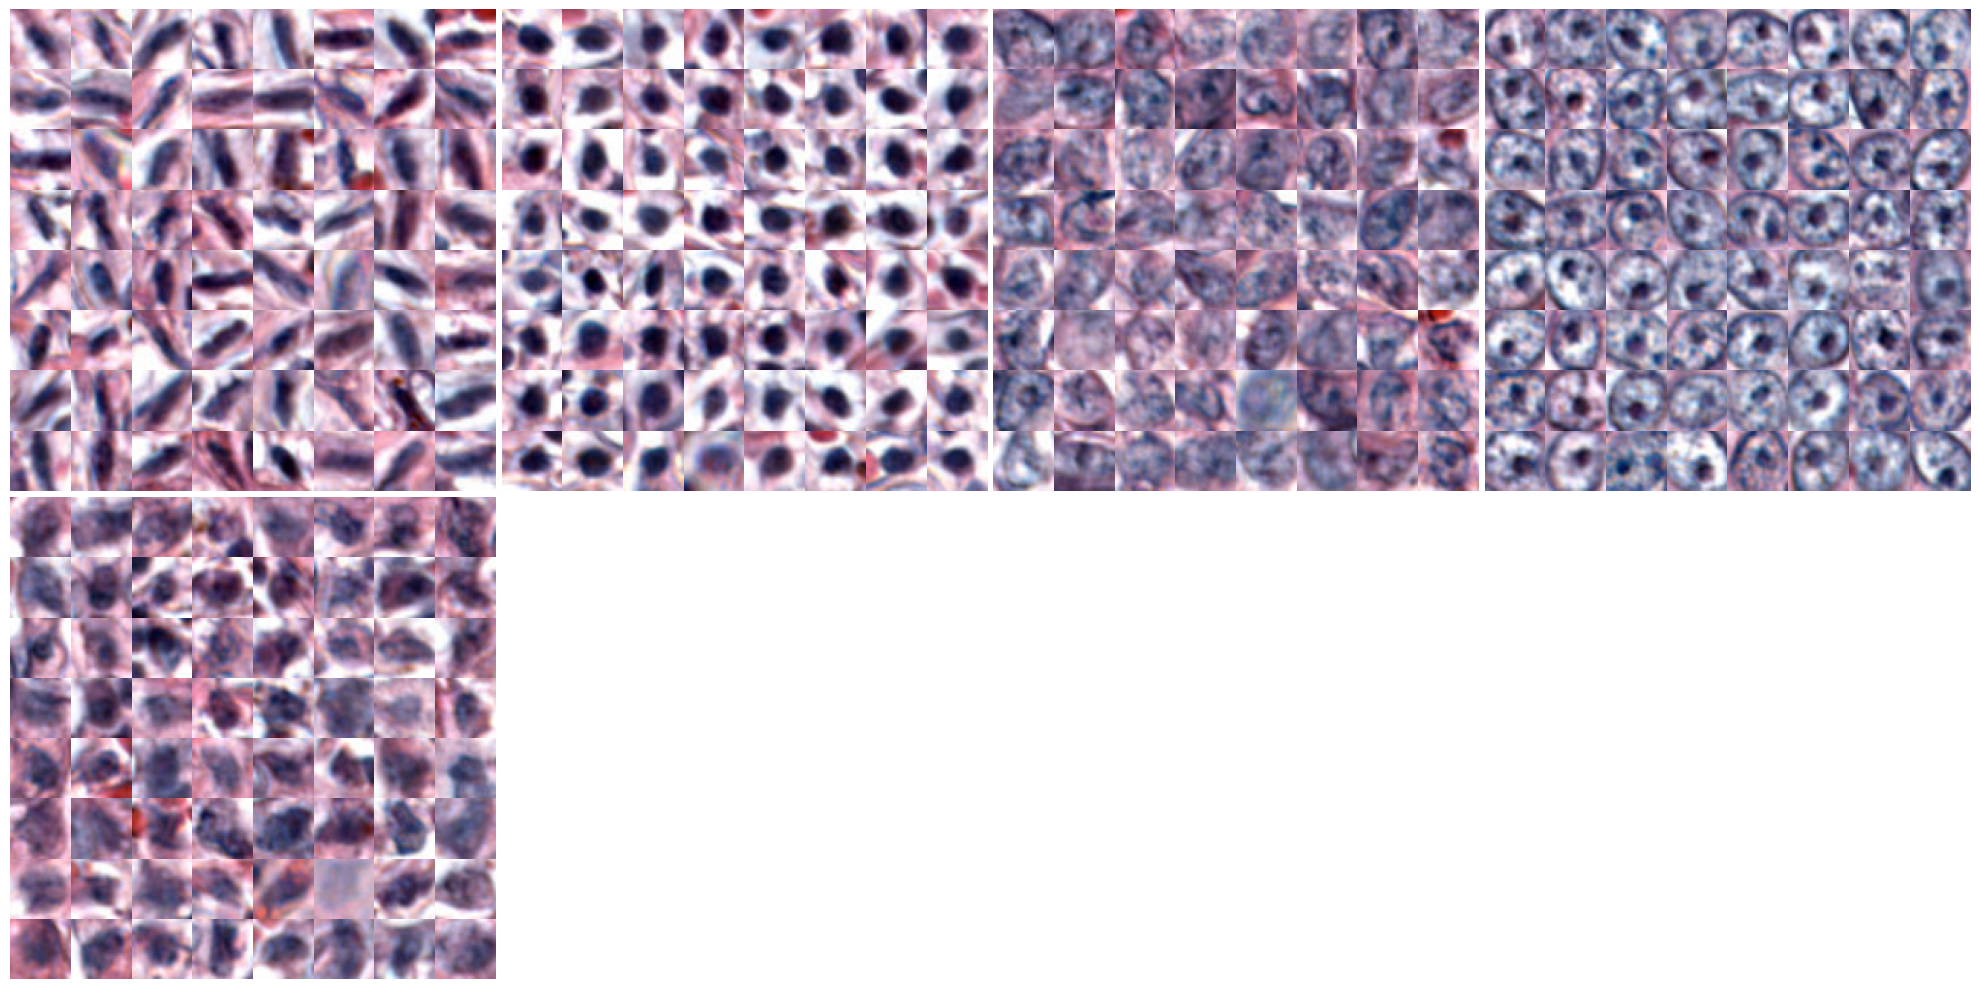

In [21]:
from utils.data_simulation import plot_cells_per_cluster

nrows = 2
ncols = 4
display = True

fig = plot_cells_per_cluster(image_dict,
                        filtered_ids,
                        filtered_labels,
                        selection="top",
                        nrows=nrows,
                        ncols=ncols,
                        display=display)
# fig.savefig("../deconv-plugin/benchmark/results/mhast/cluster_mosaic.png", dpi=300, bbox_inches="tight")

In [ ]:
# add a new cluster identical to another one

# cluster_to_duplicate = 0
# n_clusters = len(np.unique(cluster_labels))
# cluster_indices = np.where(filtered_labels == cluster_to_duplicate)[0]
# duplicate_embeddings = filtered_embeddings[cluster_indices]
# duplicate_ids = filtered_ids[cluster_indices]
# duplicate_ids = np.char.add(duplicate_ids.astype(str), "-1")

# filtered_embeddings = np.concatenate([filtered_embeddings, duplicate_embeddings], axis=0)
# filtered_ids = np.concatenate([filtered_ids, duplicate_ids], axis=0)
# filtered_labels = np.concatenate([filtered_labels, np.full(num_per_cluster, n_clusters)])

# Linear Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X = torch.stack([image_dict[i].flatten() for i in filtered_ids]).numpy()
y = np.array(filtered_labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
clf = LogisticRegression(max_iter=200, verbose=1)
clf.fit(X_train, y_train)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        49156     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.38629D+00    |proj g|=  1.37224D+01


 This problem is unconstrained.



At iterate   50    f=  8.37011D-02    |proj g|=  1.24191D+00

At iterate  100    f=  1.38189D-04    |proj g|=  1.02986D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
49156    131    149      1     0     0   9.521D-05   2.017D-05
  F =   2.0168414031107576E-005

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


LogisticRegression(max_iter=200, verbose=1)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9263
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       209
           1       0.93      0.94      0.94       213
           2       0.96      0.98      0.97       194
           3       0.88      0.92      0.90       184

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



# Simulate Visium spots

## Create bags

In [18]:
from utils.data_simulation import create_bags

mean_cell_per_bag = 5
var_cell_per_bag = 5
balance = "auto" # xeniumlike = [3.5, 0.5, 22, 2, 0.5, 4.5, 2], [4.5, 0.5, 1, 2]
not_mixed = None

total_number_of_bags = 30

bags, n_cells_per_cluster = create_bags(filtered_ids, 
                                         filtered_labels, 
                                         mean_cell_per_bag=mean_cell_per_bag, 
                                         var_cell_per_bag=var_cell_per_bag, 
                                         balance=balance,
                                         total_number_of_bags=total_number_of_bags,
                                         not_mixed=not_mixed,
                                         random_state=random_state)

Using cluster proportions: [0.25 0.25 0.25 0.25]


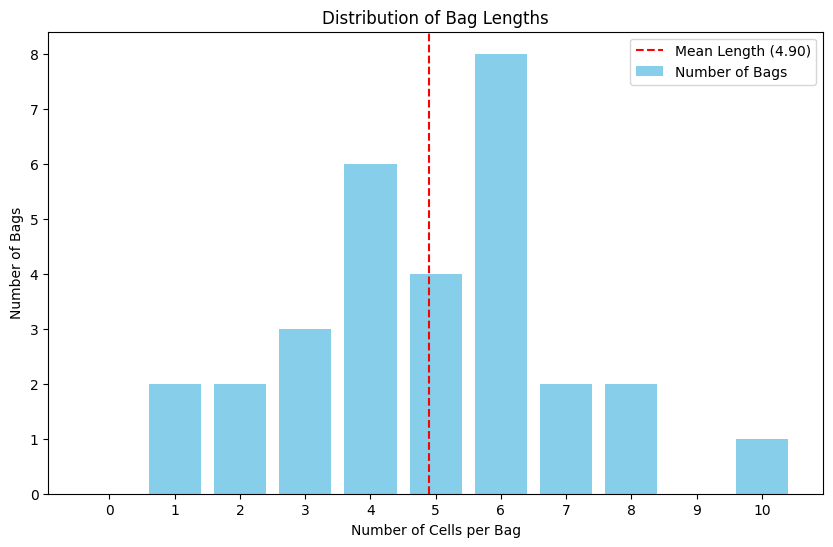

In [19]:
import matplotlib.pyplot as plt

bag_lengths = [len(bag) for bag in bags]
mean_length = np.mean(bag_lengths)

x_range = range(0, max(bag_lengths) + 1)
length_counts = [bag_lengths.count(x) for x in x_range]

plt.figure(figsize=(10, 6))
plt.bar(x_range, length_counts, color='skyblue', label='Number of Bags')
plt.axvline(x=mean_length, color='red', linestyle='--', label=f'Mean Length ({mean_length:.2f})')
plt.xlabel('Number of Cells per Bag')
plt.ylabel('Number of Bags')
plt.title('Distribution of Bag Lengths')
plt.xticks(x_range)
plt.legend()
plt.show()

/home/luca/Documents/HEDeST/simulations/full_simulations/dataset_construction/utils/data_simulation.py:394: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Cluster", y="Cell Count", palette="viridis")


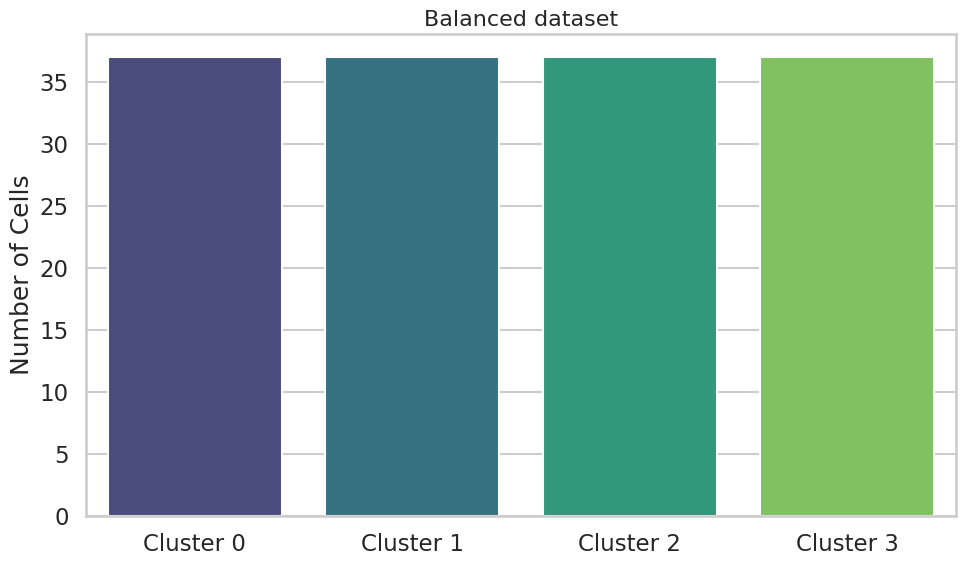

In [20]:
from utils.data_simulation import plot_cluster_distribution

plot_cluster_distribution(filtered_labels=filtered_labels, 
                              n_cells_per_cluster=n_cells_per_cluster, 
                              title='Balanced dataset',
                            #   savefig='../HEDeST/benchmark/results/mhast/Ovarian_Cancer_full_simulation/fig/distributions_reallike.png'
                            )

## Get bag proportions

In [21]:
from utils.data_simulation import get_bag_proportions

bag_proportions = get_bag_proportions(bags, filtered_ids, filtered_labels)

/home/luca/Documents/HEDeST/simulations/full_simulations/dataset_construction/utils/data_simulation.py:336: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bag_prop_df = bag_prop_df.fillna(0)


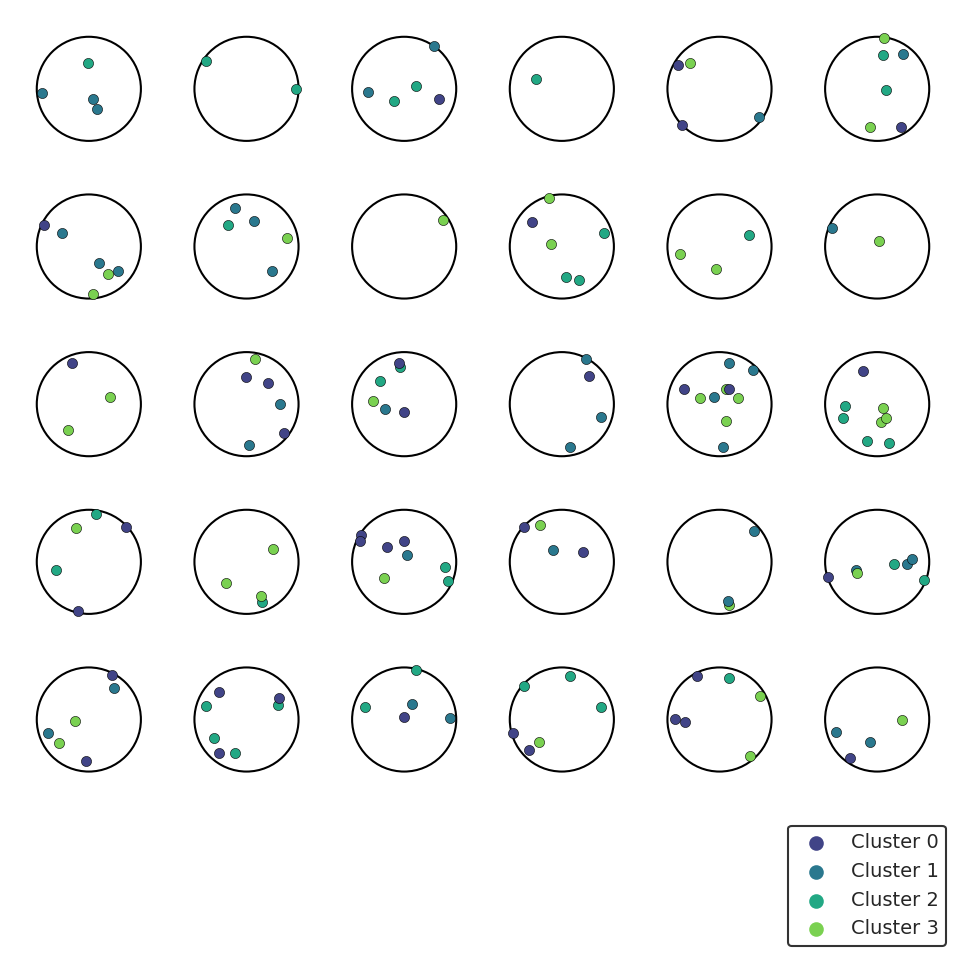

In [22]:
from utils.data_simulation import plot_bags

plot_bags(bags, 
           filtered_ids, 
           filtered_labels,
           fig_edge_size=10,
        #    savefig="../HEDeST/benchmark/results/mhast/Ovarian_Cancer_full_simulation/fig/bags_balanced.png"
           )

# Save simulated data

In [14]:
output_path = "/home/luca/Documents/data/CytAssist_11mm_FFPE_Human_Ovarian_Carcinoma/sim"
tag = "4_moco_clusters_30spots_reallike_5mean_5var"

## Spot proportions

In [15]:
filename = f"{tag}_prop.csv"
bag_proportions.to_csv(os.path.join(output_path, filename), index=True)

In [ ]:
from utils.data_simulation import add_perturbation

strength = 0.5
bag_proportions_perturbed = add_perturbation(bag_proportions, strength=strength)

filename = f"{tag}_prop.csv"
bag_proportions_perturbed.to_csv(os.path.join(output_path, filename), index=True)

## Cell to spot dictionnary

In [16]:
from collections import defaultdict

spot_dict = defaultdict(list)
for spot_id, cell_list in enumerate(bags):
    spot_dict[str(spot_id)] = cell_list

In [17]:
filename = f"{tag}_spot_dict.json"
with open(os.path.join(output_path, filename), "w") as file:
    json.dump(dict(spot_dict), file)

## Reduced Image dictionnary

In [18]:
import re

def sort_key(cell_id):
    match = re.match(r"(\d+)(?:-(\d+))?", cell_id)
    if match:
        main_id = int(match.group(1))
        sub_id = int(match.group(2)) if match.group(2) else -1
        return (main_id, sub_id)
    return (float('inf'), float('inf'))

In [19]:
valid_cell_ids = {cell_id for cell_list in spot_dict.values() for cell_id in cell_list}
sorted_cell_ids = sorted(valid_cell_ids, key=sort_key)
filtered_image_dict = {
    cell_id: image_dict[cell_id.split('-')[0]]
    for cell_id in sorted_cell_ids
    if cell_id.split('-')[0] in image_dict
}

In [20]:
filename = f"{tag}_image_dict_64.pt"
torch.save(filtered_image_dict, os.path.join(output_path, filename))

## Reduced embedding dictionnary

In [21]:
reduced_emb = {
    cell_id: embeddings_dict[cell_id.split('-')[0]]
    for cell_id in filtered_image_dict
    if cell_id.split('-')[0] in embeddings_dict
}

In [22]:
filename = f"{tag}_emb_dict.pt"
torch.save(reduced_emb, os.path.join(output_path, filename))

## Ground Truth for each nucleus

In [23]:
import pandas as pd

ground_truth = pd.DataFrame(index=filtered_ids)
unique_clusters = np.unique(filtered_labels)

for cluster in unique_clusters:
    ground_truth[f'Cluster {cluster}'] = 0.0

for nucleus_id, cluster in zip(filtered_ids, filtered_labels):
    ground_truth.at[nucleus_id, f'Cluster {cluster}'] = 1.0

ground_truth = ground_truth[ground_truth.index.isin(valid_cell_ids)]
ground_truth.index.name = 'nucleus_id'

sorted_index = sorted(ground_truth.index, key=sort_key)
ground_truth = ground_truth.loc[sorted_index]
ground_truth.index = ground_truth.index.astype(str)
ground_truth

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
nucleus_id,,,,
17900,0.0,0.0,0.0,1.0
29689,0.0,0.0,1.0,0.0
30444,0.0,1.0,0.0,0.0
31067,0.0,0.0,0.0,1.0
39003,0.0,0.0,0.0,1.0
...,...,...,...,...
349121,1.0,0.0,0.0,0.0
349186,1.0,0.0,0.0,0.0
349891,0.0,0.0,0.0,1.0


In [24]:
filename = f"{tag}_gt.csv"
ground_truth.to_csv(os.path.join(output_path, filename), index=True)